# Cancer Survival Analysis using Synthetic TCGA Dataset

## Project Overview
This project demonstrates a bioinformatics workflow similar to studies using data from The Cancer Genome Atlas (TCGA).

We analyze a synthetic cancer dataset containing:

• Gene expression values  
• Patient clinical information  
• Cancer stage  
• Survival time  

## Objectives
1. Load and explore genomic data
2. Identify highly expressed genes
3. Visualize gene expression patterns
4. Perform survival analysis using Kaplan–Meier curves
5. Compare survival across cancer stages

## Tools Used
Python  
Pandas  
Seaborn  
Matplotlib  
Lifelines (Survival Analysis)

## Expected Outcome
We will discover potential biomarker genes and visualize patient survival probabilities based on tumor characteristics.

This workflow simulates a real cancer genomics analysis pipeline used in precision oncology research.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4ab0dceead039ba5954c80d22da2c445fb823682ea65955a67e19ba3437517de
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Saving tcga_cancer_dataset.csv to tcga_cancer_dataset (1).csv
Dataset shape: (200, 55)

Preview of dataset:
  Patient_ID    GENE_1    GENE_2    GENE_3     GENE_4    GENE_5    GENE_6  \
0   TCGA_001  7.993428  6.723471  8.295377  10.046060  6.531693  6.531726   
1   TCGA_002  7.648168  6.229835  5.646156   8.223353  9.061999  8.862560   
2   TCGA_003  4.169259  6.158709  6.314571   5.395445  6.677429  7.808102   
3   TCGA_004  7.500986  7.692896  5.639951   7.464507  7.586145  5.571297   
4   TCGA_005  7.715575  8.121569  9.166102   9.107604  4.244661  5.124350   

      GENE_7    GENE_8    GENE_9  ...   GENE_45   GENE_46   GENE_47   GENE_48  \
0  10.158426  8.534869  6.061051  ...  4.042956  5.560312  6.078722  9.114244   
1   5.321565  6.381575  7.662527  ...  6.215784  4.072970  7.592241  7.522111   
2  10.772372  7.349156  7.515101  ...  7.519766  8.563646  4.526099  4.359087   
3  10.731549  7.947666  4.617393  ...  7.346362  7.770635  5.232285  7.307450   
4   8.030071  8.027572  

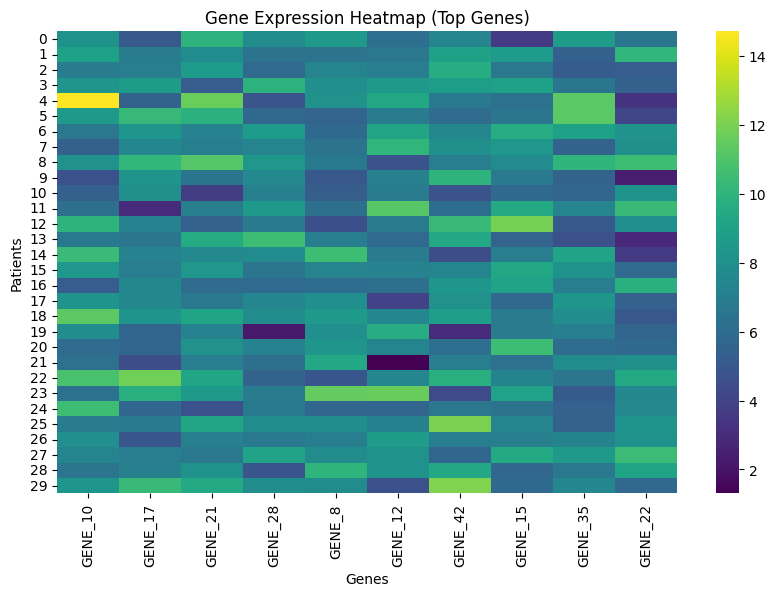

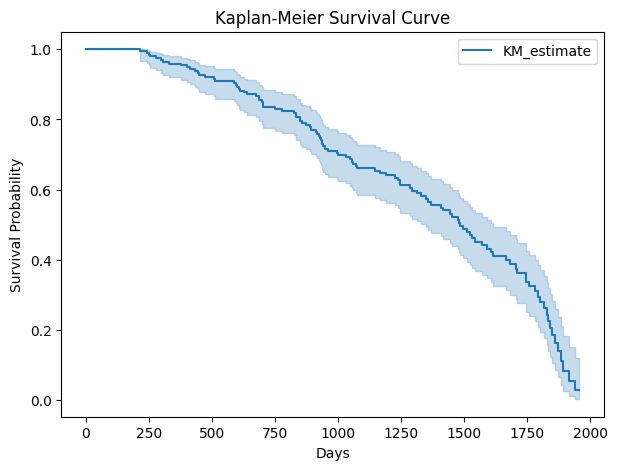

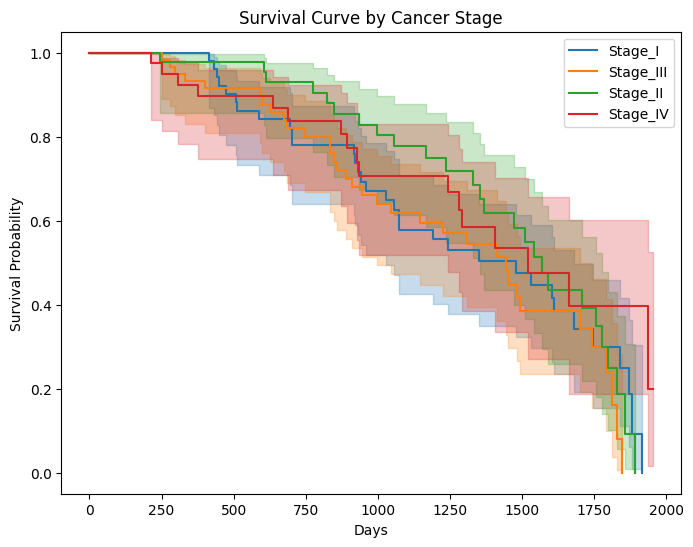

In [2]:
# Install required package for survival analysis
!pip install lifelines

# Upload dataset from computer
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Load dataset
data = pd.read_csv("tcga_cancer_dataset.csv")

print("Dataset shape:", data.shape)
print("\nPreview of dataset:")
print(data.head())

# -----------------------------
# Basic Data Exploration
# -----------------------------

print("\nColumn Names:")
print(data.columns)

print("\nCancer Stage Distribution:")
print(data["Stage"].value_counts())

print("\nSurvival Status Distribution:")
print(data["Status"].value_counts())


# -----------------------------
# Identify Highly Expressed Genes
# -----------------------------

gene_columns = [col for col in data.columns if "GENE" in col]

gene_means = data[gene_columns].mean()

top_genes = gene_means.sort_values(ascending=False).head(10)

print("\nTop 10 Highly Expressed Genes:")
print(top_genes)


# -----------------------------
# Heatmap Visualization
# -----------------------------

plt.figure(figsize=(10,6))

sns.heatmap(data[top_genes.index].head(30), cmap="viridis")

plt.title("Gene Expression Heatmap (Top Genes)")
plt.xlabel("Genes")
plt.ylabel("Patients")

plt.show()


# -----------------------------
# Kaplan-Meier Survival Analysis
# -----------------------------

kmf = KaplanMeierFitter()

T = data["Survival_days"]

E = data["Status"].apply(lambda x: 1 if x == "Dead" else 0)

kmf.fit(T, event_observed=E)

plt.figure(figsize=(7,5))

kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days")
plt.ylabel("Survival Probability")

plt.show()


# -----------------------------
# Survival Analysis by Cancer Stage
# -----------------------------

plt.figure(figsize=(8,6))

for stage in data["Stage"].unique():

    subset = data[data["Stage"] == stage]

    T = subset["Survival_days"]

    E = subset["Status"].apply(lambda x: 1 if x == "Dead" else 0)

    kmf.fit(T, event_observed=E, label=stage)

    kmf.plot_survival_function()

plt.title("Survival Curve by Cancer Stage")
plt.xlabel("Days")
plt.ylabel("Survival Probability")

plt.show()